Tutorial: Working with Shapefiles and NetCDF in Python
========
This tutorial introduces key geospatial analysis workflows using Python:
- Reading shapefiles and converting to `shapely` geometries
- Testing if coordinates fall inside polygons
- Visualising spatial data and geographic boundaries
- Reading and analysing gridded NetCDF rainfall datasets
- Creating spatial masks and integrating values over regions

We’ll focus on the Murray-Darling Basin (MDB) as a case study.

### Import Required Libraries

We begin by importing essential Python libraries:

- `numpy` for numerical operations
- `netCDF4` for handling NetCDF files
- `matplotlib.pyplot` for plotting
- `pyshp` (via `shapefile.Reader`) for shapefiles
- `shapely.geometry` to convert and operate on vector shapes

In [1]:
import numpy as np
import netCDF4 as nc
import matplotlib.pyplot as plt
from shapefile import Reader
from shapely.geometry import Point, shape

###  Load and Convert Shapefiles to Geometry
For this tutorial, we will use the MDB boundaries shapefile. Download the shapefiles from <a href="https://data.gadopt.org/water-course/MDB_boundaries.zip" download>here</a> and unzip it in the current directory.  Use `Reader()` to load two shapefiles for the MDB: one for the **north** and one for the **south**.
Convert each to a `shapely` geometry object so we can do spatial queries.

This enables operations like containment tests (`Point.within(polygon)`, i.e., if a point is inside a polygon).


In [2]:
# Load the north and south MDB shapefiles and convert each to a shapely shape
NMDB = Reader("MDB_boundaries/MDB_north_boundary.shp")
SMDB = Reader("MDB_boundaries/MDB_south_boundary.shp")
# Convert each to a shapely shape
NMDB_shape = shape(NMDB.shape())
SMDB_shape = shape(SMDB.shape())

### Check if a Point Lies Within the Basin

Check if the point (151°E, 29°S) lies in either basin.
`Point().within(polygon)` returns `True` if the point lies *inside* the shape.

In [3]:
print(Point([151, -29]).within(NMDB_shape))
print(Point([151, -29]).within(SMDB_shape))

True
False


### Plot Basin Boundaries and Test Coordinate
Extract the coordinate arrays from the shapefiles and plot them.
Overlay the test point to confirm visually.

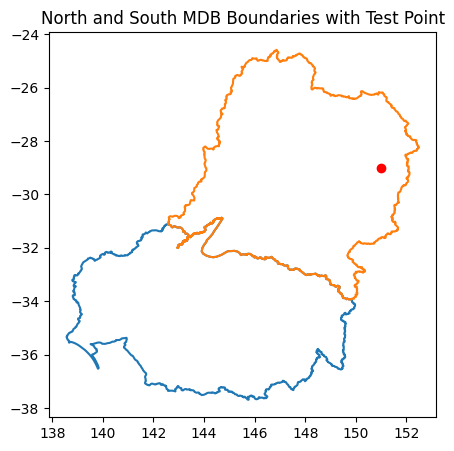

In [4]:
# Extract the coordinate arrays from the shapefiles and plot them.
NMDB_coords = np.array(NMDB.shape().points)
SMDB_coords = np.array(SMDB.shape().points)
# Plot the north and south boundaries
plt.figure(figsize=(5, 5))
plt.plot(SMDB_coords[:, 0], SMDB_coords[:, 1])
plt.plot(NMDB_coords[:, 0], NMDB_coords[:, 1])
plt.scatter(151, -29, c='red')
plt.title("North and South MDB Boundaries with Test Point")
plt.show()

### Load and Explore Rainfall Data
Download the `rain_day_2025.nc`, which is the amount of rain on 27th of July 2025 as downloaded from BoM, from <a href="https://data.gadopt.org/water-course/rain_day_2025.nc" download>here</a>. This file is in NetCDF format, which is a common format for gridded data. If you want to learn more about NetCDF, you can read the <a href="https://pro.arcgis.com/en/pro-app/latest/help/data/multidimensional/what-is-netcdf-data.htm" target="_blank">NetCDF Quick Start Guide</a>.
Open the `rain_day_2025.nc` NetCDF file and extract:
- Rainfall values
- Latitude/longitude grids
- Time axis (convert to years)

NetCDF is ideal for gridded data like daily rainfall.

In [5]:
# Load the NetCDF file and extract the rainfall data, latitude, longitude, and time
data = nc.Dataset("rain_day_2025.nc")
# Extract the rainfall data, latitude, longitude, and time
rain_day = data["rain_day"][:]
# Extract the latitude and longitude data
lats = data["latitude"][:]
lons = data["longitude"][:]
time = data["time"][:] / 365.25 + 1900  # convert from days since 1900

### Create Spatial Masks for Each Basin
We want to isolate grid cells that fall within the MDB.
Loop through the lat/lon grid and use `Point.within()` to assign `True` to cells inside the north or south basin.


In [6]:
# Build boolean masks for NMDB and SMDB based on which grid points fall inside each
NMDB_mask = np.zeros((len(lats), len(lons)))
SMDB_mask = np.zeros((len(lats), len(lons)))
# Loop through the lat/lon grid and use `Point.within()` to assign `True` to cells inside the north or south basin.
for ilat in range(len(lats)):
    for ilon in range(len(lons)):
        pt = Point([lons[ilon], lats[ilat]])
        if pt.within(NMDB_shape):
            NMDB_mask[ilat, ilon] = True
        elif pt.within(SMDB_shape):
            SMDB_mask[ilat, ilon] = True

### Plot the Mask to Verify Coverage
Combine the north and south masks, and plot to confirm the shape of the coverage.


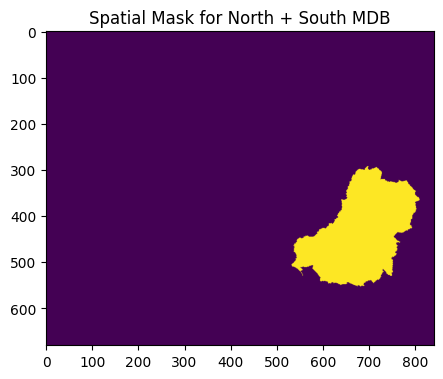

In [7]:
# Combine the north and south masks, and plot to confirm the shape of the coverage.
MDB_mask = NMDB_mask + SMDB_mask
plt.figure(figsize=(5, 5))
plt.imshow(MDB_mask)
plt.title("Spatial Mask for North + South MDB")
plt.show()

### Visualise Rainfall for a Single Day
Mask the rainfall data at one time step (e.g. day 0) using the MDB mask.
This reveals only the rainfall within the basin.

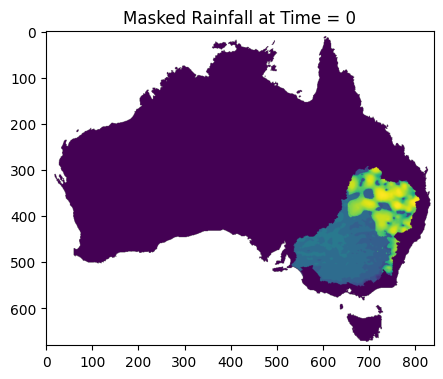

In [8]:
plt.figure(figsize=(5, 5))
plt.imshow(rain_day[0] * MDB_mask)
plt.title("Masked Rainfall at Time = 0")
plt.show()

### Integrate Rainfall Over Time
Calculate the spatially averaged rainfall over the MDB at each time step.
This gives a time series of total rainfall.

In [9]:
MDB_total_rain = np.zeros(len(time))
for i in range(len(time)):
    MDB_total_rain[i] = np.sum(MDB_mask * rain_day[i]) / np.sum(MDB_mask)

### Plot Time Series of Integrated Rainfall
Finally, plot the time series of total MDB rainfall to observe temporal patterns.

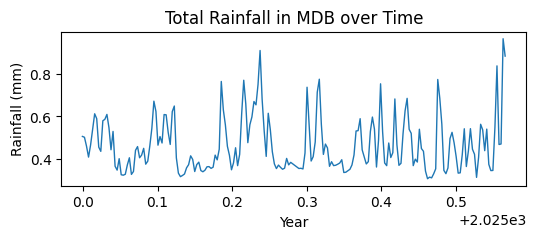

In [10]:
plt.figure(figsize=(6, 2))
# Plot the time series of total MDB rainfall
plt.plot(time, MDB_total_rain, linewidth=1)
# Set the x and y labels
plt.xlabel("Year")
plt.ylabel("Rainfall (mm)")
plt.title("Total Rainfall in MDB over Time")
plt.show()

### ✅ Extensions
To go further, try:
- Integrating rainfall separately for NMDB and SMDB
- Comparing trends or seasonal cycles between them
- Exporting the rainfall time series to CSV for reporting